# 01 — Low-Level Audio Feature Exploration (KCL Dataset)

compute several low-level features, visualise them, and compare PD vs HC groups from the KCL Parkinson's dataset, 


### Features covered
| # | Feature | What it tells us |
|---|---------|------------------|
| 1 | **Waveform & basic metadata** | Duration, sample rate, amplitude range |
| 2 | **Short-Time Energy (STE)** | Loudness over time — frame by frame |
| 3 | **Root Mean Square Energy (RMS)** | Smoothed energy envelope |
| 4 | **Zero-Crossing Rate (ZCR)** | How "noisy" vs "tonal" the signal is |
| 5 | **Fundamental Frequency (F0)** | Pitch — the vibration rate of the vocal folds |
| 6 | **Intensity (dB)** | Perceived loudness in decibels |
| 7 | **Spectral Centroid** | "Brightness" — where the spectral mass sits |
| 8 | **MFCCs** | Compact representation of the spectral envelope |
| 9 | **Spectrogram** | Full time × frequency picture |

---

In [3]:
# ============================================================
# 0. Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import parselmouth
from parselmouth.praat import call
import scipy.signal
import pandas as pd
import os, glob, warnings

warnings.filterwarnings('ignore')  # suppress librosa warnings for cleaner output
plt.rcParams.update({
    'figure.figsize': (14, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print('All imports OK')

All imports OK


## 0.1 — Point this to the data

The folder structure is:
```
KCL/
├── ReadText/
│   ├── HC/    ← 21 .wav files
│   └── PD/    ← 16 .wav files
└── SpontaneousDialogue/
    ├── HC/    ← 21 .wav files
    └── PD/    ← 15 .wav files (ID18 missing)
```

In [6]:
# ============================================================
# 0.1  Configure your dataset paths here
# ============================================================
# CHANGE THESE to match your local folder structure:
DATA_ROOT = '../KCL'  # <-- adjust this

READING_HC = os.path.join(DATA_ROOT, 'ReadText', 'HC')
READING_PD = os.path.join(DATA_ROOT, 'ReadText', 'PD')
DIALOGUE_HC = os.path.join(DATA_ROOT, 'SpontaneousDialogue', 'HC')
DIALOGUE_PD = os.path.join(DATA_ROOT, 'SpontaneousDialogue', 'PD')

def list_wavs(folder):
    """Return sorted list of .wav file paths in a folder."""
    if not os.path.isdir(folder):
        print(f'WARNING: folder not found → {folder}')
        return []
    return sorted(glob.glob(os.path.join(folder, '*.wav')))

reading_hc = list_wavs(READING_HC)
reading_pd = list_wavs(READING_PD)
dialogue_hc = list_wavs(DIALOGUE_HC)
dialogue_pd = list_wavs(DIALOGUE_PD)

print(f'Reading  — HC: {len(reading_hc)}  PD: {len(reading_pd)}')
print(f'Dialogue — HC: {len(dialogue_hc)}  PD: {len(dialogue_pd)}')
print(f'Total files: {len(reading_hc)+len(reading_pd)+len(dialogue_hc)+len(dialogue_pd)}')

Reading  — HC: 21  PD: 16
Dialogue — HC: 21  PD: 15
Total files: 73


---
## 1 — Load a single file & inspect metadata
look at the .wav file attributes

In [7]:
# ============================================================
# 1. Load one example file
# ============================================================
# Pick the first PD reading file (or change to any path you want)
example_file = reading_pd[0] if reading_pd else 'ID00_hc_0_0_0.wav'
print(f'Loading: {os.path.basename(example_file)}')

# sr=None means: keep the ORIGINAL sample rate (don't resample)
y, sr = librosa.load(example_file, sr=None)

duration = len(y) / sr
print(f'Sample rate     : {sr} Hz')
print(f'Duration        : {duration:.2f} seconds')
print(f'Total samples   : {len(y):,}')
print(f'Amplitude range : [{y.min():.4f}, {y.max():.4f}]')
print(f'Data type       : {y.dtype}')

Loading: ID02_pd_2_0_0.wav
Sample rate     : 44100 Hz
Duration        : 157.56 seconds
Total samples   : 6,948,249
Amplitude range : [-0.2511, 0.2438]
Data type       : float32


### looking at the numbers

- **Sample rate (44100 Hz expected):** 44,100 amplitude measurements per second.  
  Think of it like frames-per-second in video — higher = more temporal detail.
- **Amplitude range [-1, 1]:** librosa normalises to float32.  
  The raw file is 16-bit integer (-32768 to 32767), but floats are easier to work with.
- **Duration:** total_samples ÷ sample_rate.

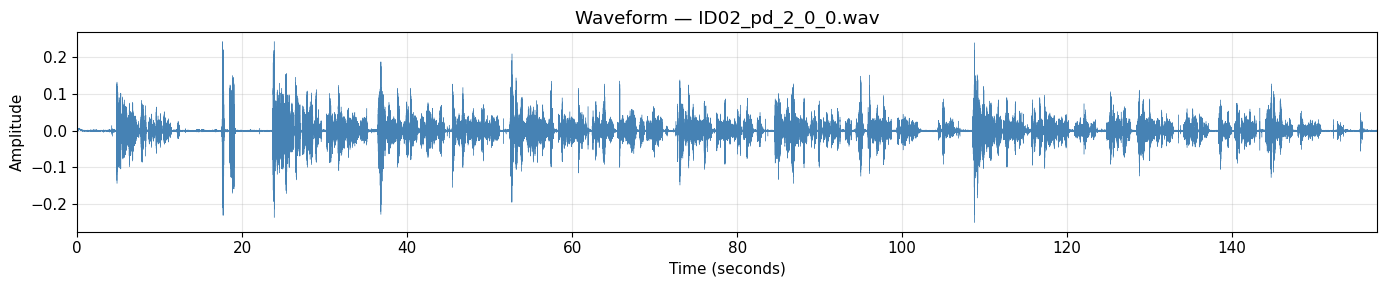

In [8]:
# ============================================================
# 1.1  Plot the raw waveform
# ============================================================
fig, ax = plt.subplots(figsize=(14, 3))
time_axis = np.arange(len(y)) / sr
ax.plot(time_axis, y, linewidth=0.3, color='steelblue')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Waveform — {os.path.basename(example_file)}')
ax.set_xlim(0, duration)
plt.tight_layout()
plt.show()

---
## 2 — Short-Time Energy (STE)

### What is it?
Raw audio oscillates rapidly (44,100 times/sec). We can't tell "loud" from "quiet"  
by looking at individual samples. Instead, we **chop the signal into short frames**  
(typically 20–30 ms each) and compute the **energy** of each frame.

### How to compute it
For a frame of N samples $x[0], x[1], \ldots, x[N-1]$:

$$E = \sum_{n=0}^{N-1} x[n]^2$$

This is just the sum of squared amplitudes — louder frames have higher energy.

### Why it matters for PD
People with Parkinson's often have **reduced and unstable loudness** (hypophonia).  
The energy contour can reveal whether someone's voice fades out or fluctuates abnormally.

Frame length: 25 ms = 1102 samples
Hop length  : 10 ms = 441 samples


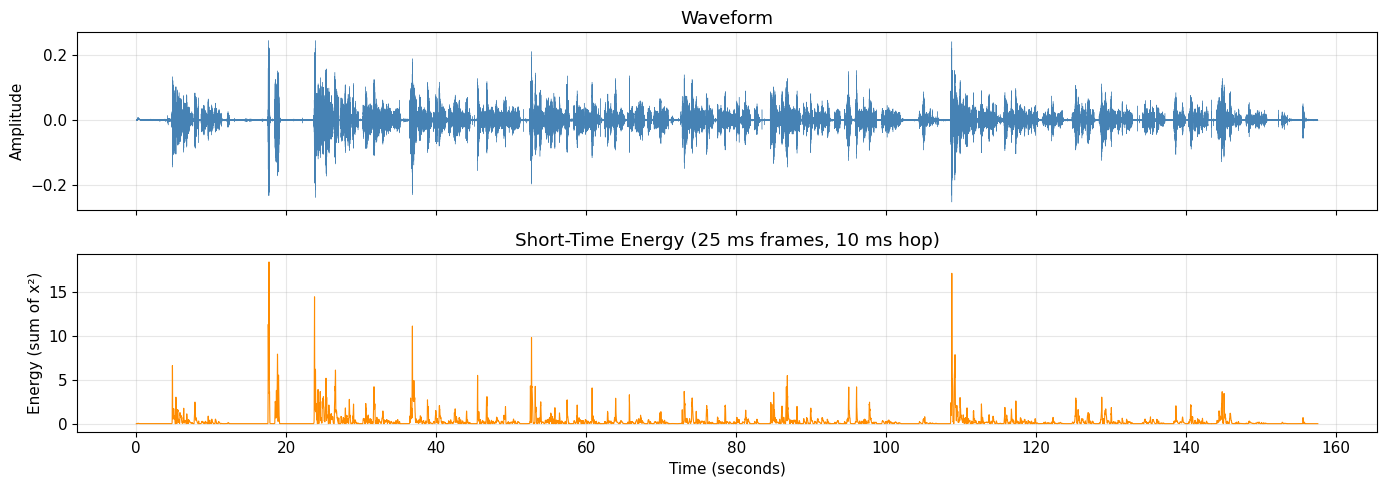


STE statistics:
  Mean energy per frame : 0.275010
  Std of energy         : 0.788898
  Max energy            : 18.410534
  Coefficient of Variation (std/mean): 2.869


In [9]:
# ============================================================
# 2. Short-Time Energy — manual implementation
# ============================================================

# --- Parameters ---
frame_length_ms = 25       # each frame is 25 ms long
hop_length_ms   = 10       # frames overlap; we step 10 ms between them

frame_length = int(sr * frame_length_ms / 1000)   # samples per frame
hop_length   = int(sr * hop_length_ms / 1000)      # samples per hop

print(f'Frame length: {frame_length_ms} ms = {frame_length} samples')
print(f'Hop length  : {hop_length_ms} ms = {hop_length} samples')

# --- Compute STE frame by frame ---
n_frames = 1 + (len(y) - frame_length) // hop_length
ste = np.zeros(n_frames)

for i in range(n_frames):
    start = i * hop_length
    frame = y[start : start + frame_length]
    ste[i] = np.sum(frame ** 2)     # <-- this is the key line

# Time axis for frames (each frame corresponds to its centre time)
frame_times = (np.arange(n_frames) * hop_length + frame_length // 2) / sr

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(time_axis, y, linewidth=0.3, color='steelblue')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Waveform')

axes[1].plot(frame_times, ste, linewidth=0.8, color='darkorange')
axes[1].set_ylabel('Energy (sum of x²)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('Short-Time Energy (25 ms frames, 10 ms hop)')

plt.tight_layout()
plt.show()

print(f'\nSTE statistics:')
print(f'  Mean energy per frame : {ste.mean():.6f}')
print(f'  Std of energy         : {ste.std():.6f}')
print(f'  Max energy            : {ste.max():.6f}')
print(f'  Coefficient of Variation (std/mean): {ste.std()/ste.mean():.3f}')

### What is the "Coefficient of Variation"?
It's just std ÷ mean. A **high CoV** means energy is very uneven across frames  
(some frames are loud, some are near-silent). This often indicates pauses or  
unstable voice intensity — both relevant for PD.

---
## 3 — RMS Energy (librosa's version)

### What is it?
Same idea as STE, but instead of summing squares, we take the  
**Root Mean Square** — which gives a value in the same units as amplitude:

$$\text{RMS} = \sqrt{\frac{1}{N} \sum_{n=0}^{N-1} x[n]^2}$$

librosa has a built-in function for this.

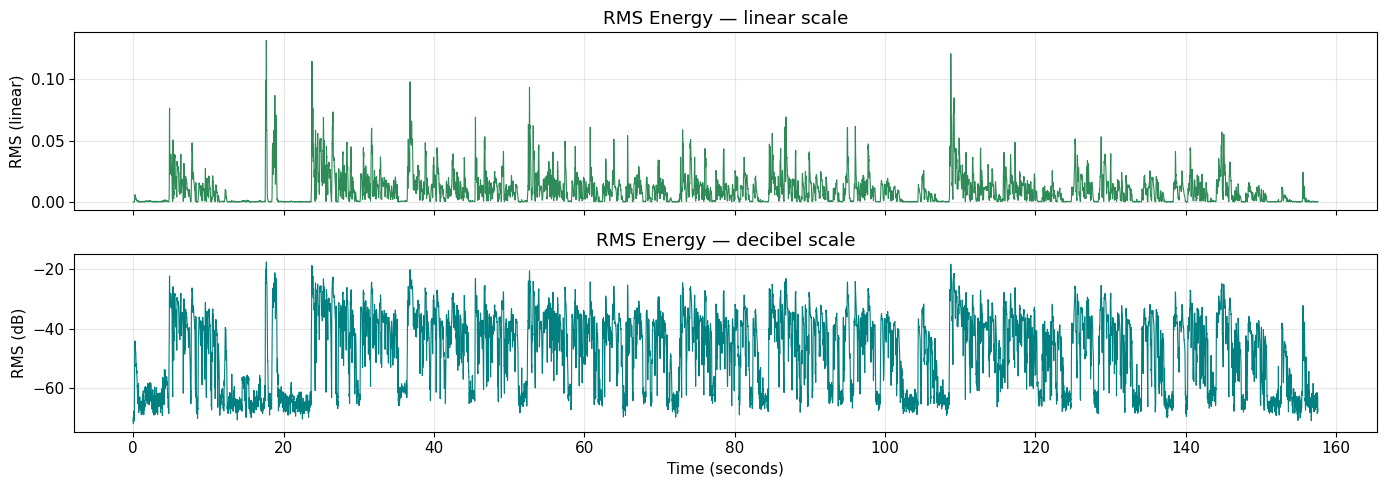

RMS stats: mean=0.0100, std=0.0122, max=0.1310


In [10]:
# ============================================================
# 3. RMS Energy using librosa
# ============================================================
rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]

# Convert to decibels for a more intuitive scale
rms_db = 20 * np.log10(rms + 1e-10)  # +1e-10 to avoid log(0)

rms_times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(rms_times, rms, linewidth=0.8, color='seagreen')
axes[0].set_ylabel('RMS (linear)')
axes[0].set_title('RMS Energy — linear scale')

axes[1].plot(rms_times, rms_db, linewidth=0.8, color='teal')
axes[1].set_ylabel('RMS (dB)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('RMS Energy — decibel scale')

plt.tight_layout()
plt.show()

print(f'RMS stats: mean={rms.mean():.4f}, std={rms.std():.4f}, max={rms.max():.4f}')

### Linear vs Decibel scale
- **Linear RMS** ranges from 0 to ~1. Differences between quiet and loud are hard to see.
- **Decibel (dB)** is logarithmic: every +6 dB ≈ doubling of amplitude.  
  This matches how humans perceive loudness. Silence → very negative dB; loud → near 0 dB.

---

## 4 — Zero-Crossing Rate (ZCR)

### What is it?
Count how many times the signal crosses the zero line (goes from positive to negative  
or vice versa) in each frame.

### Why it matters
- **Voiced speech** (vowels like "aaa", "eee"): signal is periodic → **low ZCR**
- **Unvoiced speech** (fricatives like "sss", "fff"): signal is noisy → **high ZCR**
- **Silence**: very low ZCR (near zero)

This is one of the simplest ways to tell voiced from unvoiced segments apart,  
and can help detect voice quality issues in PD speech.

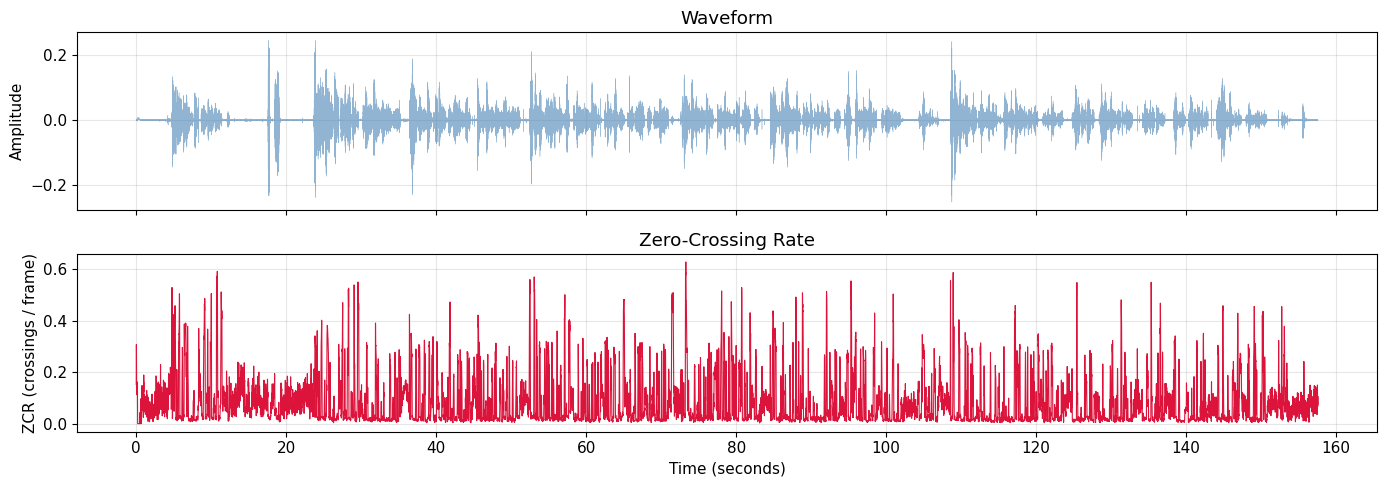

ZCR stats: mean=0.0855, std=0.0983
Notice: high ZCR regions = unvoiced consonants or noise
        low ZCR regions  = voiced speech (vowels)


In [11]:
# ============================================================
# 4. Zero-Crossing Rate
# ============================================================
zcr = librosa.feature.zero_crossing_rate(y, frame_length=frame_length, hop_length=hop_length)[0]
zcr_times = librosa.frames_to_time(np.arange(len(zcr)), sr=sr, hop_length=hop_length)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

# Show waveform with ZCR overlay
axes[0].plot(time_axis, y, linewidth=0.3, color='steelblue', alpha=0.6)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Waveform')

axes[1].plot(zcr_times, zcr, linewidth=0.8, color='crimson')
axes[1].set_ylabel('ZCR (crossings / frame)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('Zero-Crossing Rate')

plt.tight_layout()
plt.show()

print(f'ZCR stats: mean={zcr.mean():.4f}, std={zcr.std():.4f}')
print(f'Notice: high ZCR regions = unvoiced consonants or noise')
print(f'        low ZCR regions  = voiced speech (vowels)')

---
## 5 — Fundamental Frequency (F0) — the most important one

### What is it?
When you speak, your **vocal folds vibrate** at a certain rate.  
That vibration rate = the **fundamental frequency (F0)**, measured in Hz.  
This is what we perceive as **pitch**.

- Typical male F0: 85–180 Hz
- Typical female F0: 165–255 Hz

### Why it matters for PD
Parkinson's disease causes **reduced F0 range** (monotone speech) and sometimes  
**F0 instability** (tremor in the voice). The ParkCeleb study found that **F0 std  
decreases significantly** as PD progresses — the voice becomes flatter and more monotonous.

### How we compute it
We use **Praat** (via parselmouth) — the gold standard for F0 extraction in phonetics.  
It uses an **autocorrelation method** to find the dominant periodicity in each frame.

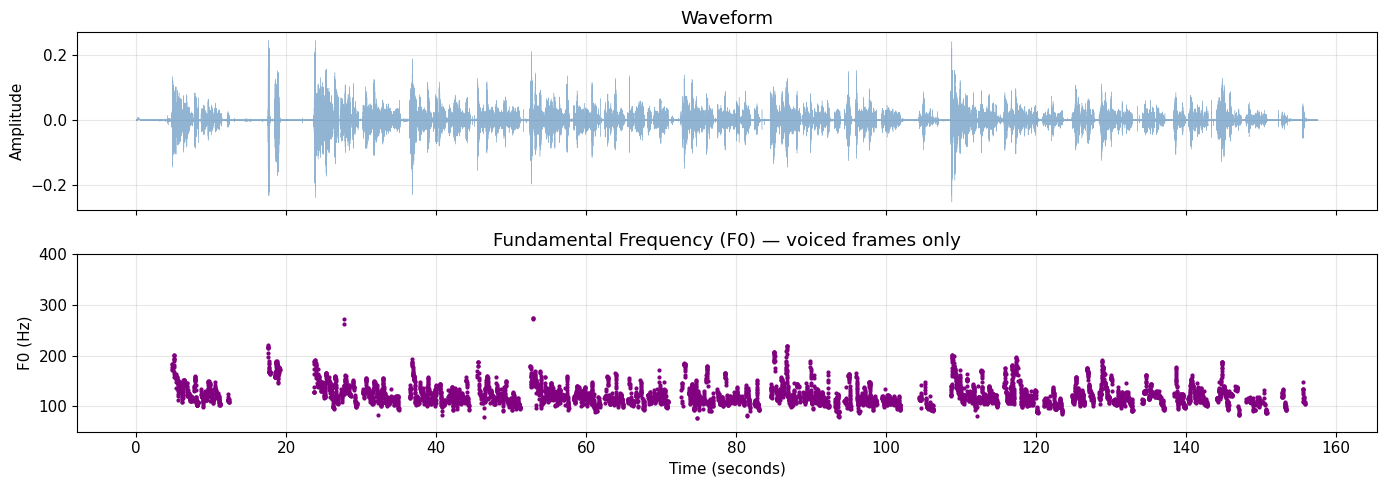


F0 statistics (voiced frames only):
  Mean F0          : 123.4 Hz
  Std F0           : 22.8 Hz
  Min F0           : 77.0 Hz
  Max F0           : 496.6 Hz
  F0 range         : 419.6 Hz
  Voicing fraction : 42.4% of frames are voiced

  → PD patients typically show LOWER F0 std (more monotone)
  → PD patients may also show LOWER voicing fraction (more pauses/unvoiced)


In [12]:
# ============================================================
# 5. Fundamental Frequency using Praat (parselmouth)
# ============================================================

# Load the audio into Praat's Sound object
snd = parselmouth.Sound(example_file)

# Extract pitch using autocorrelation method
# pitch_floor=75: don't look for F0 below 75 Hz (filters out rumble)
# pitch_ceiling=500: don't look above 500 Hz (filters out harmonics)
pitch = snd.to_pitch(
    time_step=0.01,       # compute F0 every 10 ms
    pitch_floor=75.0,     # minimum F0 to consider
    pitch_ceiling=500.0   # maximum F0 to consider
)

# Extract F0 values (0 = unvoiced frame)
f0_values = pitch.selected_array['frequency']
f0_times  = pitch.xs()  # time stamps for each F0 value

# Replace 0s (unvoiced) with NaN for cleaner plotting
f0_voiced = f0_values.copy()
f0_voiced[f0_voiced == 0] = np.nan

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(time_axis, y, linewidth=0.3, color='steelblue', alpha=0.6)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Waveform')

axes[1].plot(f0_times, f0_voiced, 'o', markersize=2, color='purple')
axes[1].set_ylabel('F0 (Hz)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('Fundamental Frequency (F0) — voiced frames only')
axes[1].set_ylim(50, 400)

plt.tight_layout()
plt.show()

# --- Statistics (voiced frames only) ---
f0_clean = f0_values[f0_values > 0]  # only voiced frames
voicing_fraction = len(f0_clean) / len(f0_values)

print(f'\nF0 statistics (voiced frames only):')
print(f'  Mean F0          : {f0_clean.mean():.1f} Hz')
print(f'  Std F0           : {f0_clean.std():.1f} Hz')
print(f'  Min F0           : {f0_clean.min():.1f} Hz')
print(f'  Max F0           : {f0_clean.max():.1f} Hz')
print(f'  F0 range         : {f0_clean.max() - f0_clean.min():.1f} Hz')
print(f'  Voicing fraction : {voicing_fraction:.1%} of frames are voiced')
print(f'\n  → PD patients typically show LOWER F0 std (more monotone)')
print(f'  → PD patients may also show LOWER voicing fraction (more pauses/unvoiced)')

---
## 6 — Intensity (dB) via Praat

### What is it?
Similar to RMS energy, but computed by Praat using a proper acoustic model.  
Measured in **dB SPL** (sound pressure level). This is the standard in phonetics.

### Why it matters for PD
PD patients often have **hypophonia** — abnormally quiet speech.  
The ParkCeleb study found that **intensity std increased** with PD progression,  
suggesting less stable loudness control.

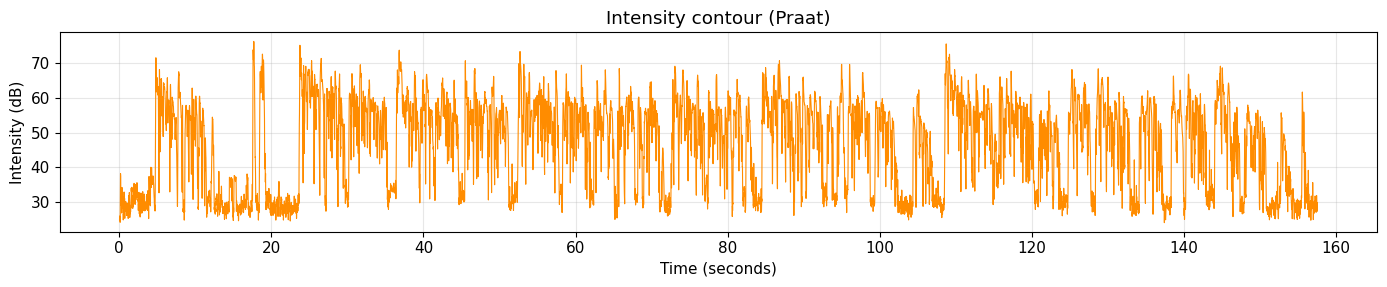

Intensity stats:
  Mean intensity : 46.9 dB
  Std intensity  : 12.5 dB
  Range          : 24.2 – 76.1 dB


In [13]:
# ============================================================
# 6. Intensity using Praat (parselmouth)
# ============================================================
intensity = snd.to_intensity(
    time_step=0.01,           # compute every 10 ms
    minimum_pitch=75.0        # same as F0 floor
)

int_values = intensity.values[0]  # intensity values in dB
int_times  = intensity.xs()       # time stamps

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(int_times, int_values, linewidth=0.8, color='darkorange')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Intensity (dB)')
ax.set_title('Intensity contour (Praat)')
plt.tight_layout()
plt.show()

print(f'Intensity stats:')
print(f'  Mean intensity : {int_values.mean():.1f} dB')
print(f'  Std intensity  : {int_values.std():.1f} dB')
print(f'  Range          : {int_values.min():.1f} – {int_values.max():.1f} dB')

---
## 7 — Spectral Centroid

### What is it?
The **centre of mass** of the frequency spectrum — where the "weight" of the  
spectrum is concentrated.

$$\text{Centroid} = \frac{\sum_k f_k \cdot S_k}{\sum_k S_k}$$

where $f_k$ is the frequency of bin $k$ and $S_k$ is the magnitude.

### Intuition
- **High centroid** → bright, sharp sound (like "sss" or high-pitched voice)
- **Low centroid** → dark, muffled sound (like "mmm" or deep voice)

### Why it matters for PD
PD can cause **imprecise articulation** and changes in vocal resonance,  
which shifts the spectral centroid.

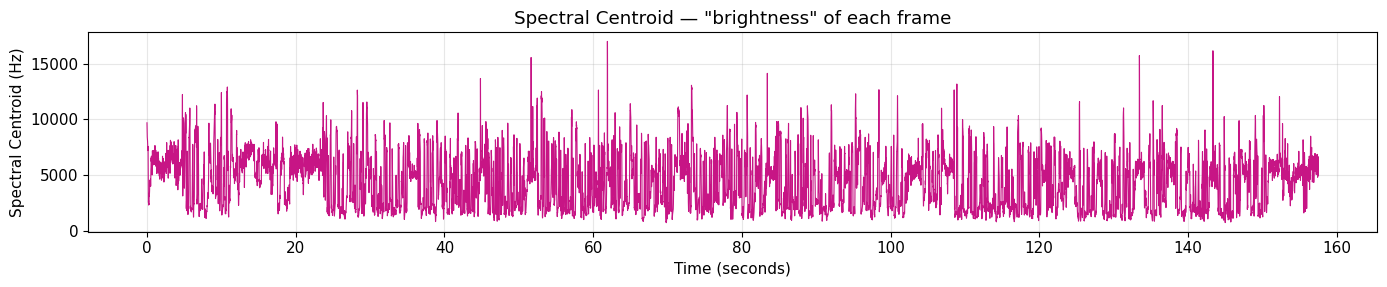

Spectral centroid stats: mean=4463 Hz, std=2434 Hz


In [14]:
# ============================================================
# 7. Spectral Centroid
# ============================================================
centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0]
centroid_times = librosa.frames_to_time(np.arange(len(centroid)), sr=sr, hop_length=hop_length)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(centroid_times, centroid, linewidth=0.8, color='mediumvioletred')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Spectral Centroid (Hz)')
ax.set_title('Spectral Centroid — "brightness" of each frame')
plt.tight_layout()
plt.show()

print(f'Spectral centroid stats: mean={centroid.mean():.0f} Hz, std={centroid.std():.0f} Hz')

---
## 8 — MFCCs (Mel-Frequency Cepstral Coefficients)

### What is it?
MFCCs are the **most widely used features** in speech processing.  
They capture the **shape of the spectral envelope** — essentially what makes  
an "ah" sound different from an "ee" sound.

### How it works (simplified)
1. Take short frames of audio
2. Compute the frequency spectrum (FFT) of each frame
3. Apply a **Mel filter bank** — a set of triangular filters that mimic  
   how humans perceive frequency (we're more sensitive to low frequencies)
4. Take the log of the filter outputs
5. Apply the **Discrete Cosine Transform (DCT)** to compress into ~13 coefficients

The result: 13 numbers per frame that compactly describe the spectral shape.

### Why it matters
- MFCC1 correlates with overall energy
- MFCC2-3 relate to the spectral slope (vowel vs consonant-like)
- Higher MFCCs capture finer spectral details
- PD can alter the MFCC distribution due to changes in articulation and resonance

MFCC matrix shape: (13, 15756)
  → 13 coefficients × 15756 frames


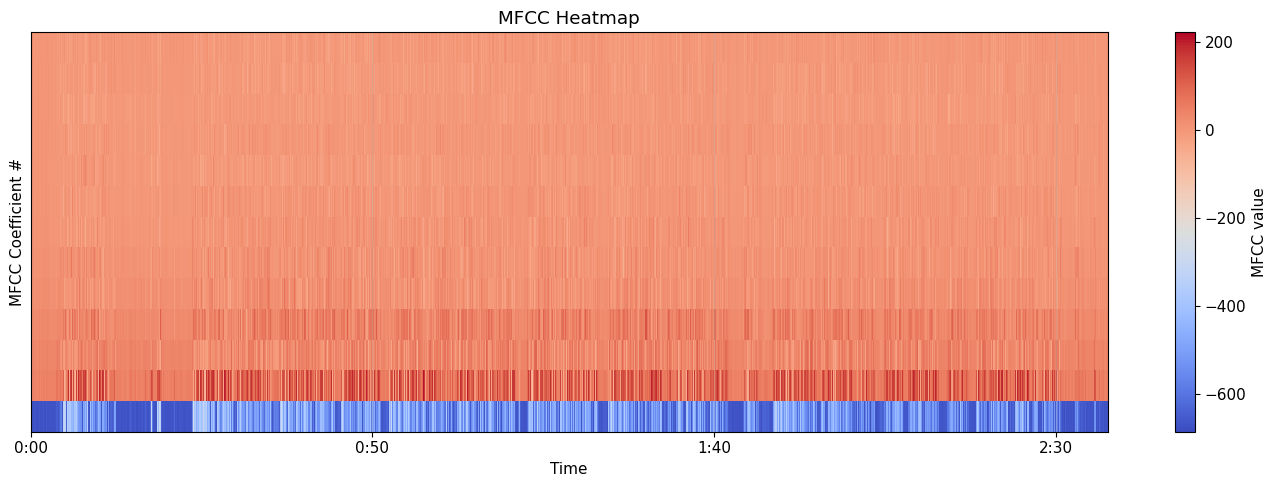


MFCC summary (mean ± std across all frames):
  MFCC  0: mean=-548.33  std=  98.06
  MFCC  1: mean=  83.05  std=  58.63
  MFCC  2: mean=  34.81  std=  26.79
  MFCC  3: mean=  41.51  std=  25.03
  MFCC  4: mean=  14.44  std=  18.74
  MFCC  5: mean=  10.35  std=  15.63
  MFCC  6: mean=   5.68  std=  13.44
  MFCC  7: mean=   3.04  std=  12.40
  MFCC  8: mean=  -2.07  std=  10.69
  MFCC  9: mean=  -0.05  std=  10.00
  MFCC 10: mean=  -4.37  std=   9.35
  MFCC 11: mean=  -4.03  std=  10.68
  MFCC 12: mean=  -1.50  std=   9.78


In [15]:
# ============================================================
# 8. MFCCs
# ============================================================
n_mfcc = 13  # standard choice

mfccs = librosa.feature.mfcc(
    y=y, sr=sr,
    n_mfcc=n_mfcc,
    n_fft=frame_length,
    hop_length=hop_length
)

print(f'MFCC matrix shape: {mfccs.shape}')
print(f'  → {mfccs.shape[0]} coefficients × {mfccs.shape[1]} frames')

fig, ax = plt.subplots(figsize=(14, 5))
img = librosa.display.specshow(
    mfccs, sr=sr, hop_length=hop_length,
    x_axis='time', ax=ax, cmap='coolwarm'
)
ax.set_ylabel('MFCC Coefficient #')
ax.set_title('MFCC Heatmap')
fig.colorbar(img, ax=ax, label='MFCC value')
plt.tight_layout()
plt.show()

# Summary statistics per coefficient
print(f'\nMFCC summary (mean ± std across all frames):')
for i in range(n_mfcc):
    print(f'  MFCC {i:2d}: mean={mfccs[i].mean():7.2f}  std={mfccs[i].std():7.2f}')

---
## 9 — Spectrogram

### What is it?
A **time-frequency representation** — it shows which frequencies are present  
at each moment in time. Computed using the Short-Time Fourier Transform (STFT).

The Mel spectrogram applies the same Mel filter bank as MFCCs  
(warping the frequency axis to match human perception).

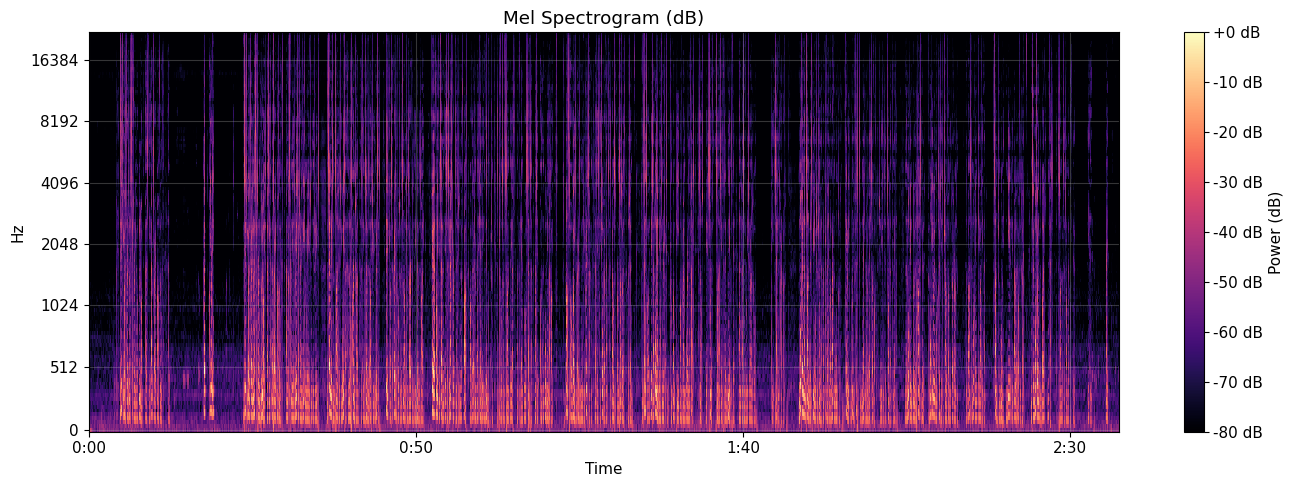

In [16]:
# ============================================================
# 9. Mel Spectrogram
# ============================================================
S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=hop_length, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

fig, ax = plt.subplots(figsize=(14, 5))
img = librosa.display.specshow(
    S_dB, sr=sr, hop_length=hop_length,
    x_axis='time', y_axis='mel', ax=ax, cmap='magma'
)
ax.set_title('Mel Spectrogram (dB)')
fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Power (dB)')
plt.tight_layout()
plt.show()

---
## 10 — Combined dashboard for one recording

Let's put everything on a single figure so you can see how the features  
relate to each other in time.

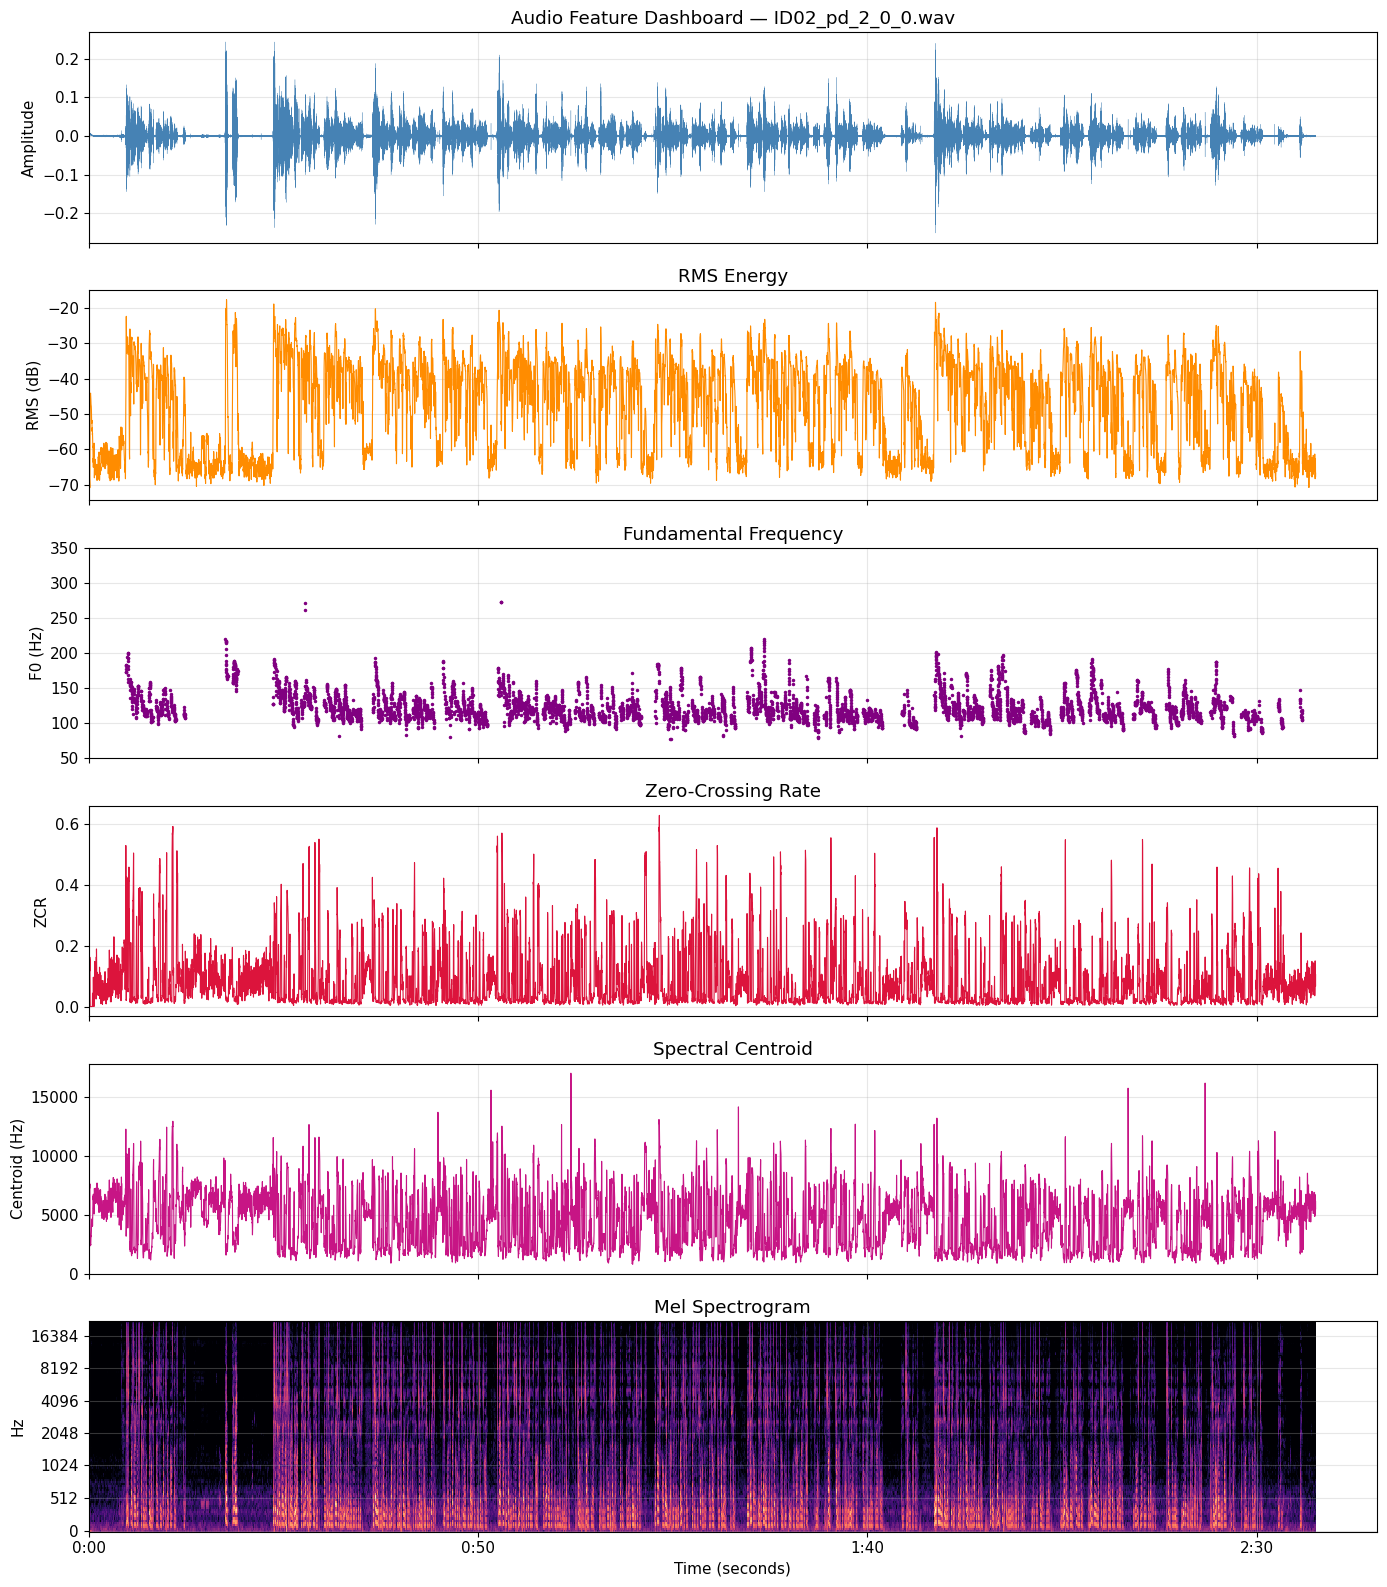

In [17]:
# ============================================================
# 10. Combined visualisation
# ============================================================
fig, axes = plt.subplots(6, 1, figsize=(14, 16), sharex=True)

# 1 — Waveform
axes[0].plot(time_axis, y, linewidth=0.2, color='steelblue')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Audio Feature Dashboard — {os.path.basename(example_file)}')

# 2 — RMS Energy (dB)
axes[1].plot(rms_times, rms_db, linewidth=0.8, color='darkorange')
axes[1].set_ylabel('RMS (dB)')
axes[1].set_title('RMS Energy')

# 3 — F0
axes[2].plot(f0_times, f0_voiced, 'o', markersize=1.5, color='purple')
axes[2].set_ylabel('F0 (Hz)')
axes[2].set_ylim(50, 350)
axes[2].set_title('Fundamental Frequency')

# 4 — ZCR
axes[3].plot(zcr_times, zcr, linewidth=0.8, color='crimson')
axes[3].set_ylabel('ZCR')
axes[3].set_title('Zero-Crossing Rate')

# 5 — Spectral Centroid
axes[4].plot(centroid_times, centroid, linewidth=0.8, color='mediumvioletred')
axes[4].set_ylabel('Centroid (Hz)')
axes[4].set_title('Spectral Centroid')

# 6 — Mel Spectrogram
librosa.display.specshow(S_dB, sr=sr, hop_length=hop_length,
                         x_axis='time', y_axis='mel', ax=axes[5], cmap='magma')
axes[5].set_title('Mel Spectrogram')

axes[5].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

---
## 11 — Batch extraction: all files → summary table

Now let's extract summary statistics from **every recording** in the dataset  
and build a DataFrame we can use for comparison.

In [18]:
# ============================================================
# 11. Batch feature extraction
# ============================================================

def extract_features(filepath):
    """
    Extract summary statistics from a single .wav file.
    Returns a dict of scalar features.
    """
    # Load audio
    y, sr = librosa.load(filepath, sr=None)
    duration = len(y) / sr
    
    # --- Frame parameters ---
    fl = int(sr * 0.025)   # 25 ms
    hl = int(sr * 0.010)   # 10 ms
    
    # --- RMS Energy ---
    rms = librosa.feature.rms(y=y, frame_length=fl, hop_length=hl)[0]
    rms_db = 20 * np.log10(rms + 1e-10)
    
    # --- ZCR ---
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=fl, hop_length=hl)[0]
    
    # --- Spectral Centroid ---
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hl)[0]
    
    # --- MFCCs ---
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=fl, hop_length=hl)
    
    # --- F0 via Praat ---
    snd = parselmouth.Sound(filepath)
    pitch = snd.to_pitch(time_step=0.01, pitch_floor=75.0, pitch_ceiling=500.0)
    f0 = pitch.selected_array['frequency']
    f0_voiced = f0[f0 > 0]
    
    # --- Intensity via Praat ---
    intensity = snd.to_intensity(time_step=0.01, minimum_pitch=75.0)
    int_vals = intensity.values[0]
    
    # --- Parse filename for labels ---
    fname = os.path.basename(filepath)
    
    # Build feature dict
    features = {
        'filename': fname,
        'duration_s': duration,
        'sample_rate': sr,
        
        # Energy
        'rms_mean': rms.mean(),
        'rms_std': rms.std(),
        'rms_db_mean': rms_db.mean(),
        'rms_db_std': rms_db.std(),
        
        # ZCR
        'zcr_mean': zcr.mean(),
        'zcr_std': zcr.std(),
        
        # Spectral Centroid
        'centroid_mean': centroid.mean(),
        'centroid_std': centroid.std(),
        
        # F0
        'f0_mean': f0_voiced.mean() if len(f0_voiced) > 0 else np.nan,
        'f0_std': f0_voiced.std() if len(f0_voiced) > 0 else np.nan,
        'f0_min': f0_voiced.min() if len(f0_voiced) > 0 else np.nan,
        'f0_max': f0_voiced.max() if len(f0_voiced) > 0 else np.nan,
        'f0_range': (f0_voiced.max() - f0_voiced.min()) if len(f0_voiced) > 0 else np.nan,
        'voicing_fraction': len(f0_voiced) / len(f0) if len(f0) > 0 else np.nan,
        
        # Intensity
        'intensity_mean': int_vals.mean(),
        'intensity_std': int_vals.std(),
    }
    
    # Add MFCC means and stds
    for i in range(13):
        features[f'mfcc{i}_mean'] = mfccs[i].mean()
        features[f'mfcc{i}_std'] = mfccs[i].std()
    
    return features


# --- Run on all files ---
all_files = []
for files, group, modality in [
    (reading_hc, 'HC', 'reading'),
    (reading_pd, 'PD', 'reading'),
    (dialogue_hc, 'HC', 'dialogue'),
    (dialogue_pd, 'PD', 'dialogue'),
]:
    for f in files:
        all_files.append((f, group, modality))

print(f'Extracting features from {len(all_files)} files...')

rows = []
for i, (fpath, group, modality) in enumerate(all_files):
    try:
        feats = extract_features(fpath)
        feats['group'] = group
        feats['modality'] = modality
        rows.append(feats)
        if (i + 1) % 10 == 0:
            print(f'  {i+1}/{len(all_files)} done...')
    except Exception as e:
        print(f'  ERROR on {os.path.basename(fpath)}: {e}')

df = pd.DataFrame(rows)
print(f'\nDone! DataFrame shape: {df.shape}')
print(f'Columns: {list(df.columns[:15])}...')
df.head()

Extracting features from 73 files...
  10/73 done...
  20/73 done...
  30/73 done...
  40/73 done...
  50/73 done...
  60/73 done...
  70/73 done...

Done! DataFrame shape: (73, 47)
Columns: ['filename', 'duration_s', 'sample_rate', 'rms_mean', 'rms_std', 'rms_db_mean', 'rms_db_std', 'zcr_mean', 'zcr_std', 'centroid_mean', 'centroid_std', 'f0_mean', 'f0_std', 'f0_min', 'f0_max']...


,filename,duration_s,sample_rate,rms_mean,rms_std,rms_db_mean,rms_db_std,zcr_mean,zcr_std,centroid_mean,...,mfcc9_mean,mfcc9_std,mfcc10_mean,mfcc10_std,mfcc11_mean,mfcc11_std,mfcc12_mean,mfcc12_std,group,modality
0,ID00_hc_0_0_0.wav,151.114717,44100,0.005123,0.005620,-51.344238,10.284541,0.078620,0.096063,4145.594909,...,-1.553212,11.854393,-0.822616,10.331245,0.890649,9.519520,-1.432103,9.121220,HC,reading
1,ID01_hc_0_0_0.wav,164.105057,44100,0.019345,0.026934,-43.170780,14.726124,0.096230,0.112019,4914.577502,...,0.303758,9.883828,-3.886753,11.902756,-3.096117,10.250099,-1.150786,8.599302,HC,reading
2,ID03_hc_0_0_0.wav,139.555329,44100,0.006407,0.006979,-49.595036,10.664822,0.086834,0.094737,4144.075978,...,-5.848605,13.340140,-8.394934,10.766158,0.686018,10.632519,-0.259822,11.435997,HC,reading
3,ID05_hc_0_0_0.wav,110.926916,44100,0.008103,0.008482,-48.545918,12.157931,0.089766,0.107378,4473.507942,...,-5.616364,14.447398,1.390907,10.080120,-4.159274,11.077290,-2.037219,10.764044,HC,reading
4,ID08_hc_0_0_0.wav,146.104762,44100,0.005192,0.005941,-51.453247,10.855470,0.096108,0.109856,4454.372304,...,1.933959,13.053653,0.438565,10.612340,-2.105214,9.757086,-1.961567,8.562154,HC,reading


---
## 12 — Compare PD vs HC

Now the fun part — let's see if any features visibly differ between groups.

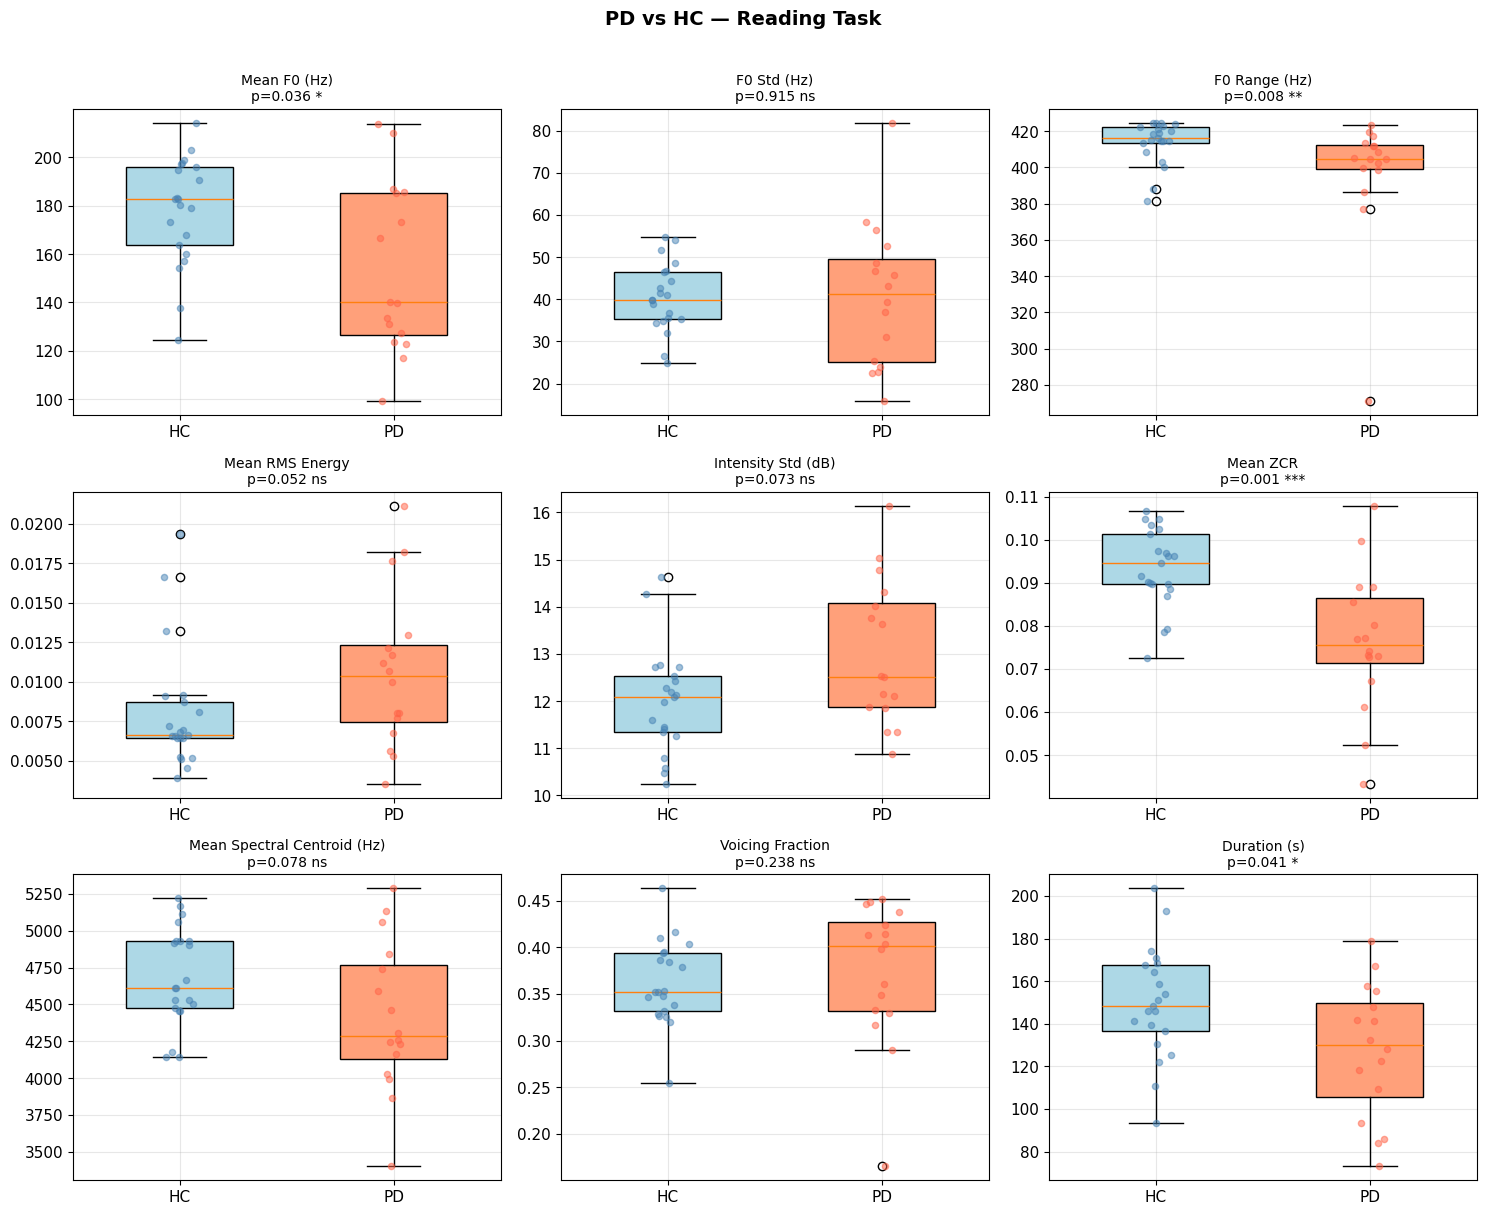

Significance: * p<0.05  ** p<0.01  *** p<0.001  ns = not significant
Note: with n=37, only large effects will reach significance.


In [19]:
# ============================================================
# 12. Group comparison plots
# ============================================================
from scipy import stats

# Features to compare
compare_features = [
    ('f0_mean', 'Mean F0 (Hz)', 'PD patients may show reduced F0'),
    ('f0_std', 'F0 Std (Hz)', 'Lower = more monotone (expected in PD)'),
    ('f0_range', 'F0 Range (Hz)', 'Narrower range in PD'),
    ('rms_mean', 'Mean RMS Energy', 'Lower = softer voice (hypophonia)'),
    ('intensity_std', 'Intensity Std (dB)', 'Unstable loudness in PD'),
    ('zcr_mean', 'Mean ZCR', 'May differ due to articulation changes'),
    ('centroid_mean', 'Mean Spectral Centroid (Hz)', 'Resonance changes in PD'),
    ('voicing_fraction', 'Voicing Fraction', 'More pauses/unvoiced in PD'),
    ('duration_s', 'Duration (s)', 'PD may read slower'),
]

# Only look at reading task for now (cleaner comparison)
df_read = df[df['modality'] == 'reading'].copy()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, (feat, label, note) in enumerate(compare_features):
    ax = axes[idx]
    hc_vals = df_read[df_read['group'] == 'HC'][feat].dropna()
    pd_vals = df_read[df_read['group'] == 'PD'][feat].dropna()
    
    # Box plot
    bp = ax.boxplot(
        [hc_vals, pd_vals],
        labels=['HC', 'PD'],
        patch_artist=True,
        widths=0.5
    )
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightsalmon')
    
    # Overlay data points
    ax.scatter(np.ones(len(hc_vals)) + np.random.normal(0, 0.04, len(hc_vals)),
               hc_vals, alpha=0.5, s=20, color='steelblue', zorder=3)
    ax.scatter(2*np.ones(len(pd_vals)) + np.random.normal(0, 0.04, len(pd_vals)),
               pd_vals, alpha=0.5, s=20, color='tomato', zorder=3)
    
    # Mann-Whitney U test
    if len(hc_vals) > 2 and len(pd_vals) > 2:
        u_stat, p_val = stats.mannwhitneyu(hc_vals, pd_vals, alternative='two-sided')
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        ax.set_title(f'{label}\np={p_val:.3f} {sig}', fontsize=10)
    else:
        ax.set_title(label, fontsize=10)

plt.suptitle('PD vs HC — Reading Task', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Significance: * p<0.05  ** p<0.01  *** p<0.001  ns = not significant')
print('Note: with n=37, only large effects will reach significance.')

In [20]:
# ============================================================
# 12.1  Summary statistics table
# ============================================================
key_features = ['f0_mean', 'f0_std', 'f0_range', 'rms_mean', 
                'intensity_std', 'zcr_mean', 'centroid_mean', 
                'voicing_fraction', 'duration_s']

summary = df_read.groupby('group')[key_features].agg(['mean', 'std']).round(3)
print('Summary statistics — Reading Task')
print('=' * 80)
summary

Summary statistics — Reading Task


f0_mean          f0_std         f0_range         rms_mean         \
          mean     std    mean     std     mean     std     mean    std   
group                                                                     
HC     178.060  22.482  40.498   8.141  413.852  11.792    0.008  0.004   
PD     153.542  35.254  40.677  17.172  397.219  35.662    0.011  0.005   

      intensity_std        zcr_mean        centroid_mean           \
               mean    std     mean    std          mean      std   
group                                                               
HC           11.995  1.118    0.093  0.009      4689.178  332.220   
PD           13.017  1.535    0.076  0.016      4413.278  505.502   

      voicing_fraction        duration_s          
                  mean    std       mean     std  
group                                             
HC               0.362  0.045    149.771  26.044  
PD               0.374  0.076    127.254  31.563

In [21]:
# ============================================================
# 12.2  Effect sizes (Cohen's d)
# ============================================================

def cohens_d(group1, group2):
    """Compute Cohen's d for two groups."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    if pooled_std == 0:
        return 0
    return (group1.mean() - group2.mean()) / pooled_std

print(f'{"Feature":<22} {"Cohen d":>10} {"p-value":>10} {"Interpretation":<20}')
print('-' * 70)

for feat in key_features:
    hc = df_read[df_read['group'] == 'HC'][feat].dropna()
    pd_g = df_read[df_read['group'] == 'PD'][feat].dropna()
    d = cohens_d(hc, pd_g)
    _, p = stats.mannwhitneyu(hc, pd_g, alternative='two-sided')
    
    if abs(d) >= 0.8:
        interp = 'LARGE effect'
    elif abs(d) >= 0.5:
        interp = 'Medium effect'
    elif abs(d) >= 0.2:
        interp = 'Small effect'
    else:
        interp = 'Negligible'
    
    print(f'{feat:<22} {d:>10.3f} {p:>10.4f} {interp:<20}')

Feature                   Cohen d    p-value Interpretation      
----------------------------------------------------------------------
f0_mean                     0.855     0.0357 LARGE effect        
f0_std                     -0.014     0.9146 Negligible          
f0_range                    0.666     0.0080 Medium effect       
rms_mean                   -0.607     0.0516 Medium effect       
intensity_std              -0.779     0.0729 Medium effect       
zcr_mean                    1.336     0.0008 LARGE effect        
centroid_mean               0.664     0.0779 Medium effect       
voicing_fraction           -0.194     0.2379 Negligible          
duration_s                  0.789     0.0415 Medium effect       


---
## 13 — Save the feature table

Save the extracted features as a CSV so you don't have to re-extract every time.

In [22]:
# ============================================================
# 13. Save to CSV
# ============================================================
output_csv = 'kcl_audio_features.csv'
df.to_csv(output_csv, index=False)
print(f'Saved {len(df)} rows × {len(df.columns)} columns to {output_csv}')
print(f'\nFeature columns saved:')
for c in df.columns:
    print(f'  • {c}')

Saved 73 rows × 47 columns to kcl_audio_features.csv

Feature columns saved:
  • filename
  • duration_s
  • sample_rate
  • rms_mean
  • rms_std
  • rms_db_mean
  • rms_db_std
  • zcr_mean
  • zcr_std
  • centroid_mean
  • centroid_std
  • f0_mean
  • f0_std
  • f0_min
  • f0_max
  • f0_range
  • voicing_fraction
  • intensity_mean
  • intensity_std
  • mfcc0_mean
  • mfcc0_std
  • mfcc1_mean
  • mfcc1_std
  • mfcc2_mean
  • mfcc2_std
  • mfcc3_mean
  • mfcc3_std
  • mfcc4_mean
  • mfcc4_std
  • mfcc5_mean
  • mfcc5_std
  • mfcc6_mean
  • mfcc6_std
  • mfcc7_mean
  • mfcc7_std
  • mfcc8_mean
  • mfcc8_std
  • mfcc9_mean
  • mfcc9_std
  • mfcc10_mean
  • mfcc10_std
  • mfcc11_mean
  • mfcc11_std
  • mfcc12_mean
  • mfcc12_std
  • group
  • modality


---
## Quick Reference: What each feature means

| Feature | What it is | PD expectation | Tool |
|---------|-----------|----------------|------|
| **F0 mean** | Average pitch | May decrease slightly | parselmouth |
| **F0 std** | Pitch variability | ↓ Decreases (monotone) | parselmouth |
| **F0 range** | Max−Min pitch | ↓ Narrower range | parselmouth |
| **RMS mean** | Average loudness | ↓ Softer (hypophonia) | librosa |
| **RMS std** | Loudness stability | May ↑ increase (unstable) | librosa |
| **Intensity std** | Loudness stability (dB) | ↑ Increases | parselmouth |
| **ZCR mean** | Voiced vs noisy | May change with articulation | librosa |
| **Spectral centroid** | Brightness | May shift with resonance changes | librosa |
| **Voicing fraction** | % of voiced frames | ↓ More pauses in PD | parselmouth |
| **MFCCs** | Spectral envelope shape | Altered articulation | librosa |
| **Duration** | Recording length | ↑ PD reads slower | librosa |

### Next steps
1. Run this notebook on your actual KCL data
2. Look at the box plots — which features show the biggest separation?
3. Check the Cohen's d values — anything > 0.5 is interesting
4. Repeat for dialogue recordings (change `df_read` filter to `df_dial`)
5. Next notebook: **metric validation** (synthetic signals) and **model training**